In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2
import matplotlib.pyplot as plt
from latham.simulation import *
from  latham.params import *
import numpy as np
import gzip
import pickle as pkl

In [5]:
I = 3.8200000000000003
cell_params, synaptic_params, network_params = network_A(I, 1.4, 1.1, 0.01)

res = None
pkl_path = f"pkls/network_A/b_e-1.4/b_i-1.1/delta_g_k_ca-0.01/I-{I}_trace.pkl.gzip"

res = run_sim(cell_params, synaptic_params, network_params, trace_v=IndexedTraceType(39))
with gzip.open(pkl_path, "wb") as f:
    pkl.dump(res, f)

#with gzip.open(pkl_path, "rb") as f:
#    res = pkl.load(f)

Successfully initialised simulation.


100001it [01:49, 912.07it/s]                                                                                                                                                                                


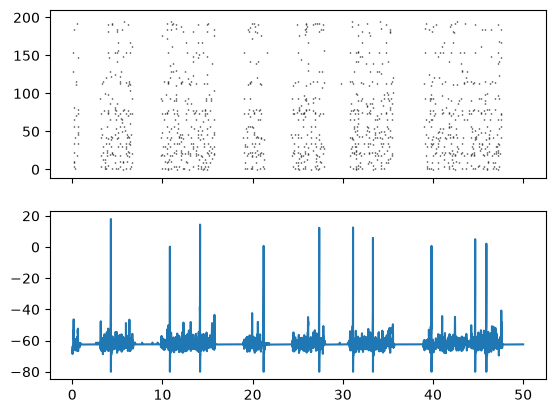

In [6]:
t, spikes, _, trace = res

fig, ax = plt.subplots(2, 1, sharex=True)

N_I = int(10000 * 0.2)
inhib = spikes[50000:,:40]
excit = spikes[50000:,N_I:N_I + 160]
t = (t[50000:] - 50000) / 1000
reduced_spikes = np.hstack((inhib, excit)).T # now indexes (neuron, time)
t_s = np.ones((200, 1)) * t
reduced_spikes = np.where(reduced_spikes, t_s, None)
reduced_spikes = [x[x.astype(bool)] for x in list(reduced_spikes)]
    

ax[0].eventplot(reduced_spikes, colors="black",lineoffsets=1,
                    linelengths=1, linewidths = 1)

ax[1].plot(t, trace[50000:])
plt.show()